In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import importlib
import pandas as pd

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/analyze_particles.ipynb
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent

for path in [
    PROJECT_DIR,
    PROJECT_DIR / "z.flow_postprocessing",
    PROJECT_DIR / "z.parcels_postprocessing",
]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)


import scripts.fieldset as pfs
import scripts.run as prun
import scripts.metrics_clustering as mclus
import scripts.metrics_flow_coupling as mcouple
import scripts.notebook_helpers as phelp
import theme.plot_theme as ptheme

for module in [pfs, prun, mclus, mcouple, phelp, ptheme]:
    importlib.reload(module)

ptheme.apply_theme()
phelp.apply_notebook_style = lambda: None

print(f"Notebook dir : {NB_DIR}")
print(f"Project dir  : {PROJECT_DIR}")
print(f"run.py loaded from: {Path(prun.__file__).resolve()}")
print(f"clustering loaded from: {Path(mclus.__file__).resolve()}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Project dir  : C:\Users\Jelle Gortemaker\Documents\Thesis
run.py loaded from: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\run.py
clustering loaded from: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\metrics_clustering.py


In [2]:
# ============================================================
# 2. CASE / COLLECTION SETTINGS
# ============================================================

case_name = "run_aug1"   
RUN_TITLE_INFO = "Case AUG-1 Production"    

INPUT_DIR = (NB_DIR / "../data/input").resolve()
DATA_FILE = (INPUT_DIR / f"{case_name}.nc").resolve()
CASE_RESULTS_DIR = (NB_DIR / f"../results/{case_name}").resolve()
METADATA_DIR = CASE_RESULTS_DIR / "metadata"
METRICS_DIR = CASE_RESULTS_DIR / "metrics"
FIG_DIR = CASE_RESULTS_DIR / "figures"

# Set to None to automatically use the newest *_config.json in metadata/.
RUN_COLLECTION_ID = None
# RUN_COLLECTION_ID = "passive_plus_mrsm_k0_release_t0000"

if RUN_COLLECTION_ID is None:
    configs = sorted(
        METADATA_DIR.glob("*_config.json"),
        key=lambda p: p.stat().st_mtime,
    )
    if len(configs) == 0:
        raise FileNotFoundError(
            f"No run collection config found in {METADATA_DIR}"
        )
    CONFIG_JSON = configs[-1]
else:
    CONFIG_JSON = METADATA_DIR / f"{RUN_COLLECTION_ID}_config.json"

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        f"Could not find run collection config:\n{CONFIG_JSON}"
    )

print(f"Using collection config: {CONFIG_JSON}")


# ============================================================
# 3. CLUSTERING / PERSISTENCE SETTINGS
# ============================================================

SAVE_FIGURES = True
SAVE_METRICS = True

SNAPSHOT_OBS_SELECTIONS = np.array([0, 3, 7, 13]) * 8

# The pooled PDF and stored intermediate PDFs use every saved
# particle snapshot from this elapsed day onward.
PDF_SKIP_INITIAL_DAYS = 2.0

# Monchaux-style PDF in nu=A/<A>.
VORONOI_BINS = np.logspace(-2.0, 1.2, 70)

# Used only when the pooled low-area PDF intersection is invalid.
CLUSTER_THRESHOLD_FALLBACK_AREA_NORM = 0.5

# Clustered-state residence settings.
MAX_UNCLUSTERED_GAP_OBS = 1
MIN_CLUSTERED_STATE_DURATION_OBS = 1
RESIDENCE_COMPLETE_EVENTS_ONLY = False

# Lagrangian Voronoï-concentration autocorrelation settings.
AUTOCORR_MAX_LAG_FRACTION = 0.5
AUTOCORR_MIN_PAIRS = 100
AUTOCORR_FIT_MIN_RHO = 0.2
AUTOCORR_FIT_MAX_RHO = 0.9

# Optional plot-label override. Keys are particle tags.
LABEL_OVERRIDES = {}


Using collection config: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\metadata\passive_plus_smmrg_k0_release_t0000_config.json


In [3]:
# ============================================================
# 4. LOAD TRAJECTORIES + DOMAIN
# ============================================================

trajectories_all, collection_config = phelp.load_trajectory_collection_from_config(
    CONFIG_JSON,
    loader=prun.load_trajectories,
    load=False,
)

LEVEL_INDICES = tuple(collection_config["level_indices"])
RELEASE_TIME_INDEX = int(collection_config["release_time_index"])
RUNTIME_DAYS = float(collection_config["runtime_days"])
TIME_STEP_SECONDS = int(collection_config["time_step_seconds"])
PERIODIC = bool(collection_config["periodic"])
level_tag = "k" + "-".join(str(k) for k in LEVEL_INDICES)

_, _, ds_parcels = pfs.build_fieldset(
    DATA_FILE,
    surface_only=True,
    mesh="flat",
    level_indices=LEVEL_INDICES,
    time_step_seconds=TIME_STEP_SECONDS,
    periodic=PERIODIC,
    add_derivatives=False,
)

Lx, Ly = phelp.get_periodic_domain_lengths(ds_parcels)
domain = mclus.domain_from_parcels_dataset(ds_parcels)

print("\nLoaded run collection")
print(f"  case           : {case_name}")
print(f"  collection     : {collection_config['run_collection_id']}")
print(f"  n classes      : {len(trajectories_all)}")
print(f"  runtime days   : {RUNTIME_DAYS}")
print(f"  domain         : {domain.Lx/1000:.1f} x {domain.Ly/1000:.1f} km")



Trajectory QC: passive
  label     : Passive particles
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\trajectories\passive_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 112}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'diameter', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'vp', 'vslip', 'z']

Trajectory QC: gdp_drifter
  label     : GDP drifter-like, tau_eff=180 s, St_s=3.313e-03
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_aug1\trajectories\gdp_drifter_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 112}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'diameter', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'vp', 'vslip', 'z']

Trajectory QC: megaplastic
  label 

In [4]:
# ============================================================
# 5. SELECT / LABEL PARTICLE CLASSES
# ============================================================

# Use None to include all.
INCLUDE_TAGS = None
INCLUDE_PARTICLE_CLASSES = None
STOKES_RANGE = None
TAU_P_RANGE_SECONDS = None

trajectories = phelp.filter_trajectories(
    trajectories_all,
    include_tags=INCLUDE_TAGS,
    include_particle_classes=INCLUDE_PARTICLE_CLASSES,
    stokes_range=STOKES_RANGE,
    tau_p_range_seconds=TAU_P_RANGE_SECONDS,
)

trajectories = phelp.apply_label_overrides(
    trajectories,
    LABEL_OVERRIDES,
)

if len(trajectories) == 0:
    raise RuntimeError("No particle classes selected.")

metadata_table = phelp.particle_metadata_table(trajectories)
display(metadata_table)

class_style_map = phelp.build_class_style_map(trajectories)

Selected particle classes:
  passive | Passive particles
  gdp_drifter | GDP drifter-like, tau_eff=180 s, St_s=3.313e-03
  megaplastic | Megaplastic-like, tau_eff=330 s, St_s=3.749e-02


,particle_tag,display_label,particle_class,tau_p_seconds,flow_timescale_seconds,stokes_number,output_path
0,passive,Passive particles,passive,None,1598400.0,0.000000,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
1,gdp_drifter,"τₚ=?, St=0.00331",mr_sm,None,1598400.0,0.003313,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...
2,megaplastic,"τₚ=?, St=0.0375",mr_sm,None,1598400.0,0.037491,C:\Users\Jelle Gortemaker\Documents\Thesis\z.p...


In [5]:
# ============================================================
# 6. COMPACT TRAJECTORY / POSITION FIGURES
# ============================================================

TRAJ_FIG_DIR = FIG_DIR / "trajectory_snapshots"

trajectory_subset_figures = phelp.plot_trajectory_subset_per_class(
    trajectories,
    Lx=Lx,
    Ly=Ly,
    run_title_info=RUN_TITLE_INFO,
    case_name=case_name,
    fig_dir=TRAJ_FIG_DIR,
    save_figures=SAVE_FIGURES,
    class_style_map=class_style_map,
    show=True,
)

position_snapshot_figures = phelp.plot_position_snapshots_combined(
    trajectories,
    obs_selections=SNAPSHOT_OBS_SELECTIONS,
    run_title_info=RUN_TITLE_INFO,
    case_name=case_name,
    fig_dir=TRAJ_FIG_DIR,
    save_figures=SAVE_FIGURES,
    class_style_map=class_style_map,
    show=True,
)


ValueError: A colormap named "toc" is already registered.

In [ ]:
# ============================================================
# 7. VORONOÏ CLUSTERING + PERSISTENCE METRICS
# ============================================================

voronoi_dir = METRICS_DIR / "voronoi"
clustered_state_dir = METRICS_DIR / "clustered_state_residence"
autocorr_dir = METRICS_DIR / "voronoi_concentration_autocorrelation"

voronoi_fig_dir = FIG_DIR / "voronoi_snapshots"
pdf_fig_dir = FIG_DIR / "voronoi_pdf"
clustered_state_fig_dir = FIG_DIR / "clustered_state_residence"
autocorr_fig_dir = FIG_DIR / "voronoi_concentration_autocorrelation"

if SAVE_METRICS:
    for directory in [
        voronoi_dir,
        clustered_state_dir,
        autocorr_dir,
    ]:
        directory.mkdir(parents=True, exist_ok=True)

if SAVE_FIGURES:
    for directory in [
        voronoi_fig_dir,
        pdf_fig_dir,
        clustered_state_fig_dir,
        autocorr_fig_dir,
    ]:
        directory.mkdir(parents=True, exist_ok=True)


reference_ds = next(iter(trajectories.values()))["ds"]
n_obs = reference_ds.sizes["obs"]
all_obs_indices = list(range(n_obs))
poisson_sigma_2d = float(np.sqrt(2.0 / 7.0))


def resolve_many(selections):
    resolved = []
    for selection in selections:
        obs_idx = phelp.resolve_obs_index(selection, n_obs)
        if 0 <= obs_idx < n_obs:
            resolved.append(obs_idx)
    return sorted(set(resolved))


def elapsed_days_for_obs(ds_traj, obs_indices):
    return np.asarray(
        [
            phelp.get_elapsed_time_days(ds_traj, int(obs_idx))
            for obs_idx in obs_indices
        ],
        dtype=float,
    )


def pdf_obs_after_day(ds_traj, skip_initial_days):
    elapsed_days = elapsed_days_for_obs(ds_traj, all_obs_indices)
    valid = (
        np.isfinite(elapsed_days)
        & (elapsed_days >= float(skip_initial_days) - 1.0e-10)
    )
    obs_indices = np.flatnonzero(valid).astype(int)

    if obs_indices.size == 0:
        raise ValueError(
            "No observations remain after applying "
            f"PDF_SKIP_INITIAL_DAYS={skip_initial_days}."
        )

    return obs_indices, elapsed_days[valid]


def summary_from_cached_areas(cluster_ts, obs_indices):
    selected = cluster_ts.sel(obs=np.asarray(obs_indices, dtype=int))
    area = np.asarray(selected["voronoi_area"].values, dtype=float)
    area_norm = np.asarray(
        selected["voronoi_area_norm"].values,
        dtype=float,
    )

    valid = np.isfinite(area) & (area > 0.0)
    masked_area = np.where(valid, area, np.nan)

    mean_area = np.nanmean(masked_area, axis=0)
    std_area = np.nanstd(masked_area, axis=0)

    return xr.Dataset(
        data_vars={
            "voronoi_area_mean": ("obs", mean_area),
            "voronoi_area_std": ("obs", std_area),
            "voronoi_area_cv": (
                "obs",
                np.divide(
                    std_area,
                    mean_area,
                    out=np.full_like(std_area, np.nan),
                    where=mean_area > 0.0,
                ),
            ),
            "voronoi_area_p05": (
                "obs",
                np.nanpercentile(masked_area, 5, axis=0),
            ),
            "voronoi_area_p50": (
                "obs",
                np.nanpercentile(masked_area, 50, axis=0),
            ),
            "voronoi_area_p95": (
                "obs",
                np.nanpercentile(masked_area, 95, axis=0),
            ),
            "voronoi_area_norm_std": (
                "obs",
                np.nanstd(area_norm, axis=0),
            ),
            "voronoi_n_cells": (
                "obs",
                np.sum(valid, axis=0).astype(int),
            ),
            "voronoi_total_area": (
                "obs",
                np.nansum(masked_area, axis=0),
            ),
        },
        coords={
            "obs": np.asarray(selected["obs"].values, dtype=int),
        },
        attrs={
            "description": (
                "Periodic Voronoi summary statistics derived from "
                "cached particle-level Voronoi areas."
            ),
            "domain_area": float(domain.area),
            "poisson_area_norm_std_2d": poisson_sigma_2d,
            "x_min": float(domain.x_min),
            "x_max": float(domain.x_max),
            "y_min": float(domain.y_min),
            "y_max": float(domain.y_max),
        },
    )


def pdf_products_from_cached_areas(
    cluster_ts,
    obs_indices,
    elapsed_days,
    bins,
):
    """
    Create pooled and per-snapshot Voronoï-area PDFs from the
    already-computed voronoi_area_norm array.

    No Voronoï tessellations are performed in this function.
    """
    area_norm_da = (
        cluster_ts["voronoi_area_norm"]
        .sel(obs=np.asarray(obs_indices, dtype=int))
        .transpose("trajectory", "obs")
    )

    area_norm = np.asarray(
        area_norm_da.values,
        dtype=float,
    )

    edges = np.asarray(bins, dtype=float)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])

    pdf_poisson = np.asarray(
        mclus.poisson_voronoi_area_pdf_2d(centers),
        dtype=float,
    )

    n_pdf_obs = area_norm.shape[1]
    n_bins = centers.size

    pdf_snapshot = np.full(
        (n_pdf_obs, n_bins),
        np.nan,
        dtype=float,
    )
    count_snapshot = np.zeros(
        (n_pdf_obs, n_bins),
        dtype=np.int64,
    )
    relative_pdf_snapshot = np.full_like(
        pdf_snapshot,
        np.nan,
    )

    sigma_snapshot = np.full(
        n_pdf_obs,
        np.nan,
        dtype=float,
    )
    heterogeneity_snapshot = np.full(
        n_pdf_obs,
        np.nan,
        dtype=float,
    )
    n_samples_snapshot = np.zeros(
        n_pdf_obs,
        dtype=np.int64,
    )
    nu_c_snapshot = np.full(
        n_pdf_obs,
        np.nan,
        dtype=float,
    )
    nu_v_snapshot = np.full(
        n_pdf_obs,
        np.nan,
        dtype=float,
    )

    pooled_values = []

    for j in range(n_pdf_obs):
        values = area_norm[:, j]

        values = values[
            np.isfinite(values)
            & (values > 0.0)
        ]

        if values.size == 0:
            continue

        pooled_values.append(values)

        counts, _ = np.histogram(
            values,
            bins=edges,
            density=False,
        )

        n_values_in_bins = int(np.sum(counts))

        if n_values_in_bins == 0:
            continue

        pdf_j = (
            counts
            / (n_values_in_bins * widths)
        )

        with np.errstate(
            divide="ignore",
            invalid="ignore",
        ):
            relative_j = pdf_j / pdf_poisson

        relative_j[~np.isfinite(relative_j)] = np.nan

        sigma_j = float(np.nanstd(values))

        count_snapshot[j] = counts
        pdf_snapshot[j] = pdf_j
        relative_pdf_snapshot[j] = relative_j

        sigma_snapshot[j] = sigma_j
        heterogeneity_snapshot[j] = (
            sigma_j / poisson_sigma_2d
        )
        n_samples_snapshot[j] = int(values.size)

        nu_c_snapshot[j] = (
            mclus.find_first_pdf_intersection(
                centers,
                pdf_j,
                pdf_poisson,
            )
        )

        nu_v_snapshot[j] = (
            mclus.find_second_pdf_intersection(
                centers,
                pdf_j,
                pdf_poisson,
            )
        )

    if len(pooled_values) == 0:
        raise ValueError(
            "No valid normalized Voronoï areas were "
            "available for the aggregate PDF."
        )

    pooled_values = np.concatenate(pooled_values)

    pooled_count, _ = np.histogram(
        pooled_values,
        bins=edges,
        density=False,
    )

    n_pooled_in_bins = int(np.sum(pooled_count))

    if n_pooled_in_bins == 0:
        raise ValueError(
            "All normalized Voronoï areas fall outside "
            "the selected PDF bins."
        )

    pooled_pdf = (
        pooled_count
        / (n_pooled_in_bins * widths)
    )

    with np.errstate(
        divide="ignore",
        invalid="ignore",
    ):
        pooled_relative = (
            pooled_pdf / pdf_poisson
        )

    pooled_relative[
        ~np.isfinite(pooled_relative)
    ] = np.nan

    nu_c = mclus.find_first_pdf_intersection(
        centers,
        pooled_pdf,
        pdf_poisson,
    )

    nu_v = mclus.find_second_pdf_intersection(
        centers,
        pooled_pdf,
        pdf_poisson,
    )

    # Basic consistency checks.
    if not np.any(pooled_count > 0):
        raise RuntimeError(
            "The aggregate Voronoï histogram is empty."
        )

    if not np.any(
        np.isfinite(pooled_pdf)
        & (pooled_pdf > 0.0)
    ):
        raise RuntimeError(
            "The aggregate Voronoï PDF contains no "
            "positive finite values."
        )

    return xr.Dataset(
        data_vars={
            # Variables required by the existing plotting function.
            "pdf": (
                "bin",
                pooled_pdf.astype(float),
            ),
            "count": (
                "bin",
                pooled_count.astype(np.int64),
            ),
            "pdf_poisson": (
                "bin",
                pdf_poisson.astype(float),
            ),
            "relative_pdf": (
                "bin",
                pooled_relative.astype(float),
            ),
            "cluster_threshold_nu_c": xr.DataArray(
                float(nu_c)
            ),
            "void_threshold_nu_v": xr.DataArray(
                float(nu_v)
            ),
            "n_samples": xr.DataArray(
                int(pooled_values.size)
            ),
            "n_samples_in_bins": xr.DataArray(
                n_pooled_in_bins
            ),

            # Per-snapshot products.
            "pdf_snapshot": (
                ("pdf_obs", "bin"),
                pdf_snapshot,
            ),
            "count_snapshot": (
                ("pdf_obs", "bin"),
                count_snapshot,
            ),
            "relative_pdf_snapshot": (
                ("pdf_obs", "bin"),
                relative_pdf_snapshot,
            ),
            "pdf_mean_snapshot": (
                "bin",
                np.nanmean(
                    pdf_snapshot,
                    axis=0,
                ),
            ),
            "pdf_median_snapshot": (
                "bin",
                np.nanmedian(
                    pdf_snapshot,
                    axis=0,
                ),
            ),
            "pdf_std_across_snapshots": (
                "bin",
                np.nanstd(
                    pdf_snapshot,
                    axis=0,
                ),
            ),
            "pdf_p10_snapshot": (
                "bin",
                np.nanpercentile(
                    pdf_snapshot,
                    10,
                    axis=0,
                ),
            ),
            "pdf_p90_snapshot": (
                "bin",
                np.nanpercentile(
                    pdf_snapshot,
                    90,
                    axis=0,
                ),
            ),
            "sigma_area_norm_snapshot": (
                "pdf_obs",
                sigma_snapshot,
            ),
            "spatial_heterogeneity_index_snapshot": (
                "pdf_obs",
                heterogeneity_snapshot,
            ),
            "n_samples_snapshot": (
                "pdf_obs",
                n_samples_snapshot,
            ),
            "cluster_threshold_nu_c_snapshot": (
                "pdf_obs",
                nu_c_snapshot,
            ),
            "void_threshold_nu_v_snapshot": (
                "pdf_obs",
                nu_v_snapshot,
            ),
        },
        coords={
            "bin": np.arange(
                n_bins,
                dtype=int,
            ),
            "nu": (
                "bin",
                centers.astype(float),
            ),
            "bin_left": (
                "bin",
                edges[:-1].astype(float),
            ),
            "bin_right": (
                "bin",
                edges[1:].astype(float),
            ),
            "pdf_obs": np.arange(
                n_pdf_obs,
                dtype=int,
            ),
            "pdf_obs_index": (
                "pdf_obs",
                np.asarray(
                    obs_indices,
                    dtype=int,
                ),
            ),
            "pdf_elapsed_days": (
                "pdf_obs",
                np.asarray(
                    elapsed_days,
                    dtype=float,
                ),
            ),
        },
        attrs={
            "description": (
                "Pooled aggregate Voronoï-area PDF and "
                "per-snapshot PDFs derived from cached "
                "normalized Voronoï areas."
            ),
            "pdf_aggregation_method": (
                "Normalized Voronoï areas pooled across "
                "the selected snapshots."
            ),
            "n_obs_aggregated": int(n_pdf_obs),
            "pdf_skip_initial_days": float(
                PDF_SKIP_INITIAL_DAYS
            ),
            "aggregate_pdf_start_day": float(
                elapsed_days[0]
            ),
            "aggregate_pdf_end_day": float(
                elapsed_days[-1]
            ),
            "poisson_area_norm_std_2d": float(
                poisson_sigma_2d
            ),
        },
    )


snapshot_obs_indices = resolve_many(SNAPSHOT_OBS_SELECTIONS)
pdf_obs_indices, pdf_elapsed_days = pdf_obs_after_day(
    reference_ds,
    PDF_SKIP_INITIAL_DAYS,
)

autocorr_max_lag_obs = max(
    1,
    min(n_obs - 1, int(AUTOCORR_MAX_LAG_FRACTION * n_obs)),
)

print(f"Snapshot obs indices : {snapshot_obs_indices}")
print(
    "PDF observations     : "
    f"{len(pdf_obs_indices)} snapshots, "
    f"day {pdf_elapsed_days[0]:.3f} to "
    f"{pdf_elapsed_days[-1]:.3f}"
)
print(f"Clustering obs count : {n_obs}")
print(f"Autocorr max lag obs : {autocorr_max_lag_obs}")


voronoi_outputs = {}
cluster_outputs = {}
clustered_state_outputs = {}
autocorr_outputs = {}

for particle_tag, item in trajectories.items():
    ds = item["ds"]
    label = item.get(
        "display_label",
        item.get("label", particle_tag),
    )

    print(f"\nProcessing clustering metrics: {particle_tag} ({label})")

    # Expensive step: exactly one periodic Voronoï tessellation
    # per observation. All other metrics reuse these cached areas.
    cluster_ts = mclus.compute_voronoi_clustering_timeseries(
        ds_traj=ds,
        obs_indices=all_obs_indices,
        domain=domain,
        threshold_method="fixed",
        fixed_threshold_area_norm=(
            CLUSTER_THRESHOLD_FALLBACK_AREA_NORM
        ),
        log_area=False,
    )

    summary = summary_from_cached_areas(
        cluster_ts,
        snapshot_obs_indices,
    )

    pdf = pdf_products_from_cached_areas(
        cluster_ts,
        pdf_obs_indices,
        pdf_elapsed_days,
        VORONOI_BINS,
    )

    class_threshold = float(pdf["cluster_threshold_nu_c"].values)
    threshold_source = (
        "aggregate_pdf_low_area_intersection_post_day_2"
    )

    if not np.isfinite(class_threshold) or class_threshold <= 0.0:
        class_threshold = float(
            CLUSTER_THRESHOLD_FALLBACK_AREA_NORM
        )
        threshold_source = "fallback_fixed_threshold"

    print(
        f"  fixed class threshold nu_c: {class_threshold:.4f} "
        f"({threshold_source})"
    )

    area_norm_ts = np.asarray(
        cluster_ts["voronoi_area_norm"].values,
        dtype=float,
    )
    cluster_flag = (
        np.isfinite(area_norm_ts)
        & (area_norm_ts < class_threshold)
    )

    cluster_ts["cluster_flag"] = (
        ("trajectory", "obs"),
        cluster_flag.astype(np.int8),
    )
    cluster_ts["cluster_threshold_area_norm"] = (
        "obs",
        np.full(n_obs, class_threshold, dtype=float),
    )
    cluster_ts.attrs.update({
        "threshold_method": "fixed",
        "fixed_threshold_area_norm": float(class_threshold),
        "threshold_source": threshold_source,
        "aggregate_pdf_obs_indices": ",".join(
            map(str, pdf_obs_indices)
        ),
        "aggregate_pdf_elapsed_days": ",".join(
            f"{day:.6g}" for day in pdf_elapsed_days
        ),
    })

    sigma_area_norm_ts = np.nanstd(area_norm_ts, axis=0)
    heterogeneity_index_ts = (
        sigma_area_norm_ts / poisson_sigma_2d
    )
    n_valid_cells_ts = np.sum(
        np.isfinite(area_norm_ts),
        axis=0,
    ).astype(int)
    cluster_elapsed_days = elapsed_days_for_obs(
        ds,
        all_obs_indices,
    )

    heterogeneity = xr.Dataset(
        data_vars={
            "sigma_area_norm": (
                "obs",
                sigma_area_norm_ts,
            ),
            "spatial_heterogeneity_index": (
                "obs",
                heterogeneity_index_ts,
            ),
            "n_valid_voronoi_cells": (
                "obs",
                n_valid_cells_ts,
            ),
            "spatial_heterogeneity_index_mean": xr.DataArray(
                float(np.nanmean(heterogeneity_index_ts))
            ),
            "spatial_heterogeneity_index_median": xr.DataArray(
                float(np.nanmedian(heterogeneity_index_ts))
            ),
            "spatial_heterogeneity_index_std_time": xr.DataArray(
                float(np.nanstd(heterogeneity_index_ts))
            ),
        },
        coords={
            "obs": np.asarray(all_obs_indices, dtype=int),
            "elapsed_days": (
                "obs",
                cluster_elapsed_days,
            ),
        },
        attrs={
            "description": (
                "Continuous Tagawa-style Voronoi "
                "spatial-heterogeneity time series."
            ),
            "definition": (
                "spatial_heterogeneity_index = "
                "std(A/<A>) / sqrt(2/7)"
            ),
            "poisson_area_norm_std_2d": poisson_sigma_2d,
        },
    )

    cluster_ts = mclus.apply_clustered_state_gap_tolerance(
        cluster_ts,
        max_unclustered_gap_obs=MAX_UNCLUSTERED_GAP_OBS,
    )

    clustered_state_events = (
        mclus.compute_clustered_state_residence_times(
            cluster_ts,
            ds_traj=ds,
            min_duration_obs=(
                MIN_CLUSTERED_STATE_DURATION_OBS
            ),
        )
    )
    clustered_state_summary = (
        mclus.clustered_state_residence_summary(
            clustered_state_events,
            complete_events_only=(
                RESIDENCE_COMPLETE_EVENTS_ONLY
            ),
        )
    )

    autocorr = (
        mclus.compute_lagrangian_voronoi_concentration_autocorrelation(
            cluster_ts,
            ds_traj=ds,
            max_lag_obs=autocorr_max_lag_obs,
            min_pairs=AUTOCORR_MIN_PAIRS,
            fit_min_rho=AUTOCORR_FIT_MIN_RHO,
            fit_max_rho=AUTOCORR_FIT_MAX_RHO,
        )
    )

    common_attrs = {
        "case_name": case_name,
        "run_title_info": RUN_TITLE_INFO,
        "particle_tag": particle_tag,
        "particle_label": label,
        "level_tag": level_tag,
        "release_time_index": int(RELEASE_TIME_INDEX),
        "runtime_days": float(RUNTIME_DAYS),
        "fixed_cluster_threshold_area_norm": float(
            class_threshold
        ),
        "threshold_source": threshold_source,
    }

    for out_ds in [
        summary,
        pdf,
        heterogeneity,
        cluster_ts,
        clustered_state_events,
        clustered_state_summary,
        autocorr,
    ]:
        out_ds.attrs.update(common_attrs)

        for key, value in list(out_ds.attrs.items()):
            if isinstance(value, (bool, np.bool_)):
                out_ds.attrs[key] = int(value)

    voronoi_outputs[particle_tag] = {
        "summary": summary,
        "pdf": pdf,
        "heterogeneity": heterogeneity,
    }
    cluster_outputs[particle_tag] = cluster_ts
    clustered_state_outputs[particle_tag] = {
        "events": clustered_state_events,
        "summary": clustered_state_summary,
    }
    autocorr_outputs[particle_tag] = autocorr

    if SAVE_METRICS:
        stem = (
            f"{particle_tag}_{level_tag}_"
            f"release_t{RELEASE_TIME_INDEX:04d}"
        )

        summary_path = voronoi_dir / f"{stem}_summary.nc"
        pdf_path = voronoi_dir / f"{stem}_aggregate_pdf.nc"
        heterogeneity_path = (
            voronoi_dir
            / f"{stem}_heterogeneity_timeseries.nc"
        )
        cluster_path = (
            voronoi_dir
            / f"{stem}_clustered_state_timeseries.nc"
        )
        events_path = (
            clustered_state_dir
            / f"{stem}_clustered_state_events.nc"
        )
        events_summary_path = (
            clustered_state_dir
            / f"{stem}_clustered_state_summary.nc"
        )
        autocorr_path = (
            autocorr_dir
            / f"{stem}_voronoi_concentration_autocorrelation.nc"
        )

        summary.to_netcdf(summary_path)
        pdf.to_netcdf(pdf_path)
        heterogeneity.to_netcdf(heterogeneity_path)
        cluster_ts.to_netcdf(cluster_path)
        clustered_state_events.to_netcdf(events_path)
        clustered_state_summary.to_netcdf(
            events_summary_path
        )
        autocorr.to_netcdf(autocorr_path)

        print(f"  saved summary              : {summary_path.name}")
        print(f"  saved aggregate PDF        : {pdf_path.name}")
        print(
            "  saved heterogeneity series : "
            f"{heterogeneity_path.name}"
        )
        print(
            "  saved clustered-state flags: "
            f"{cluster_path.name}"
        )
        print(
            "  saved residence episodes   : "
            f"{events_path.name}"
        )
        print(
            "  saved autocorrelation      : "
            f"{autocorr_path.name}"
        )

print("\nDone computing clustering and persistence metrics.")


Snapshot obs indices : [0, 24, 56, 104]
PDF observations     : 96 snapshots, day 2.000 to 13.875
Clustering obs count : 112
Autocorr max lag obs : 56

Processing clustering metrics: passive (Passive particles)
  fixed class threshold nu_c: 0.4637 (aggregate_pdf_low_area_intersection_post_day_2)
  saved summary              : passive_k0_release_t0000_summary.nc
  saved aggregate PDF        : passive_k0_release_t0000_aggregate_pdf.nc
  saved heterogeneity series : passive_k0_release_t0000_heterogeneity_timeseries.nc
  saved clustered-state flags: passive_k0_release_t0000_clustered_state_timeseries.nc
  saved residence episodes   : passive_k0_release_t0000_clustered_state_events.nc
  saved autocorrelation      : passive_k0_release_t0000_voronoi_concentration_autocorrelation.nc

Processing clustering metrics: smmrg_taueff30s_Steff1p82742em05 (τₚ=30 s, St=1.83e-05)
  fixed class threshold nu_c: 0.4587 (aggregate_pdf_low_area_intersection_post_day_2)
  saved summary              : smmrg_taue

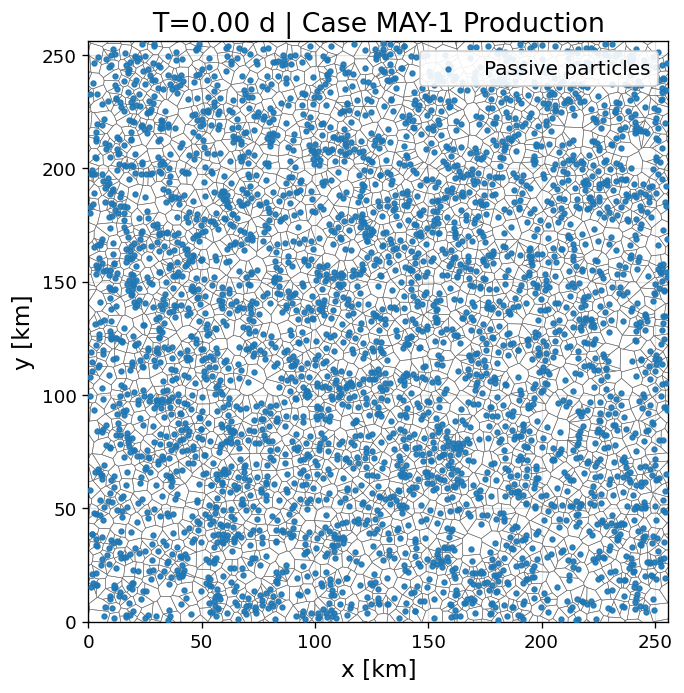

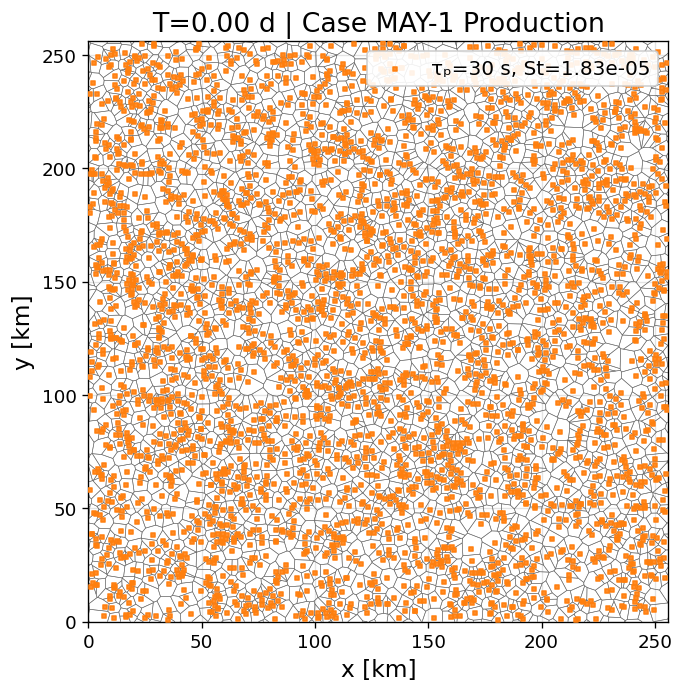

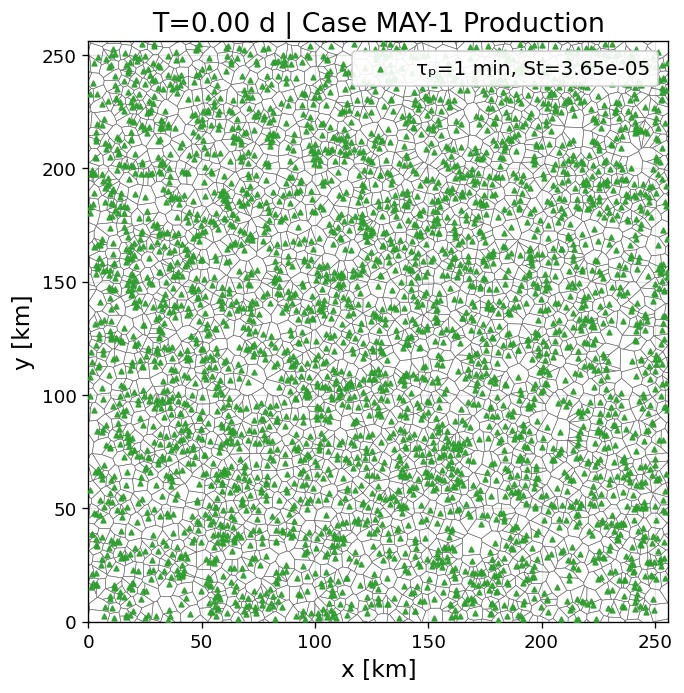

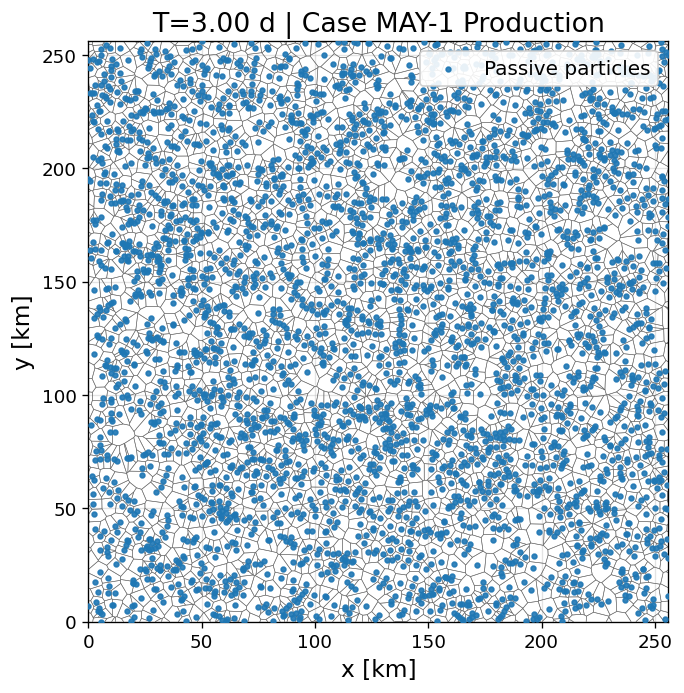

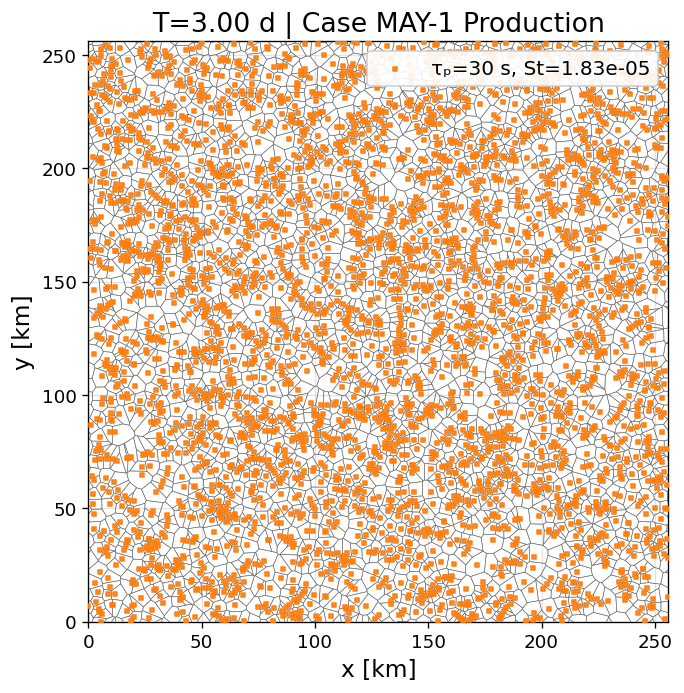

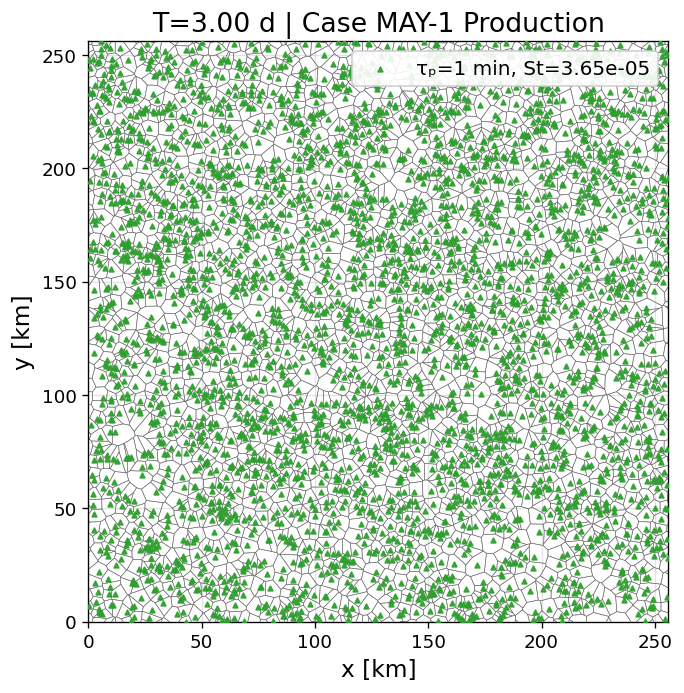

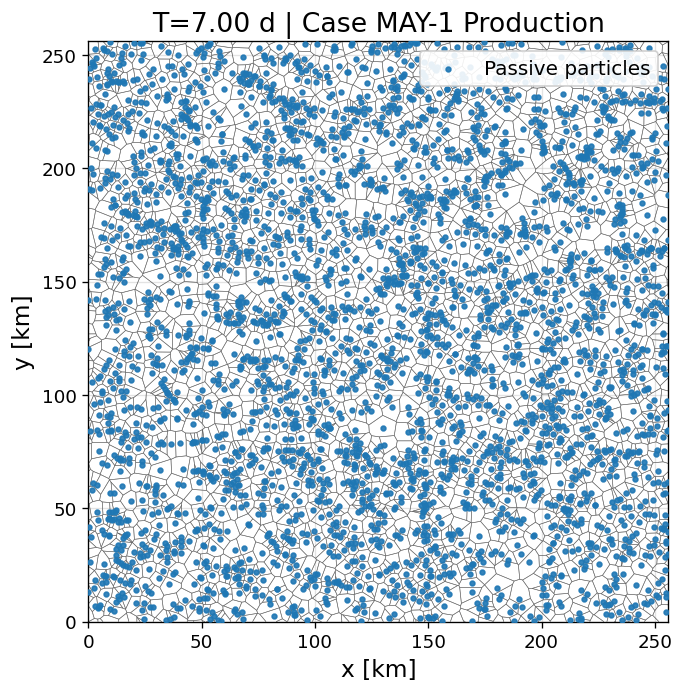

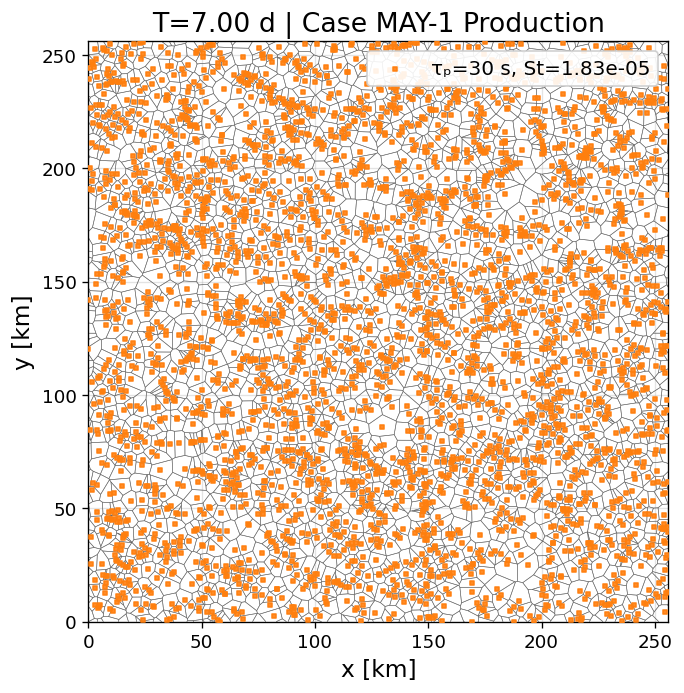

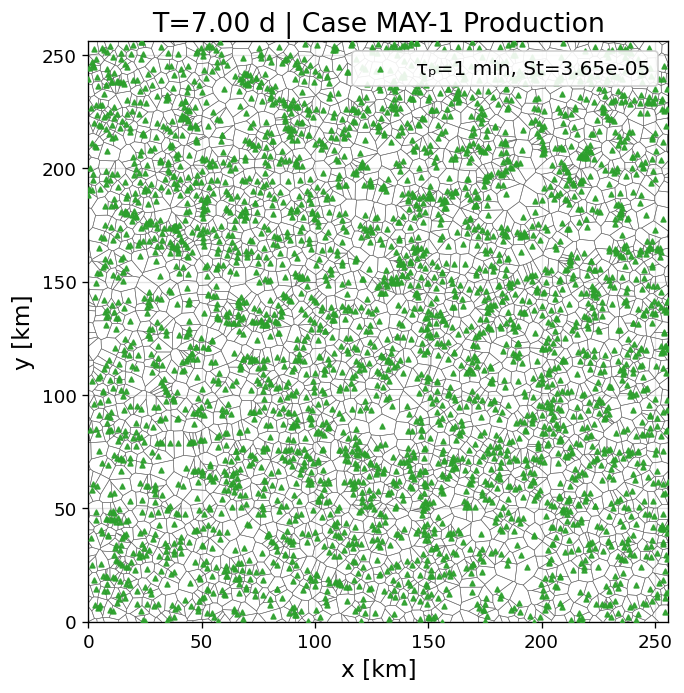

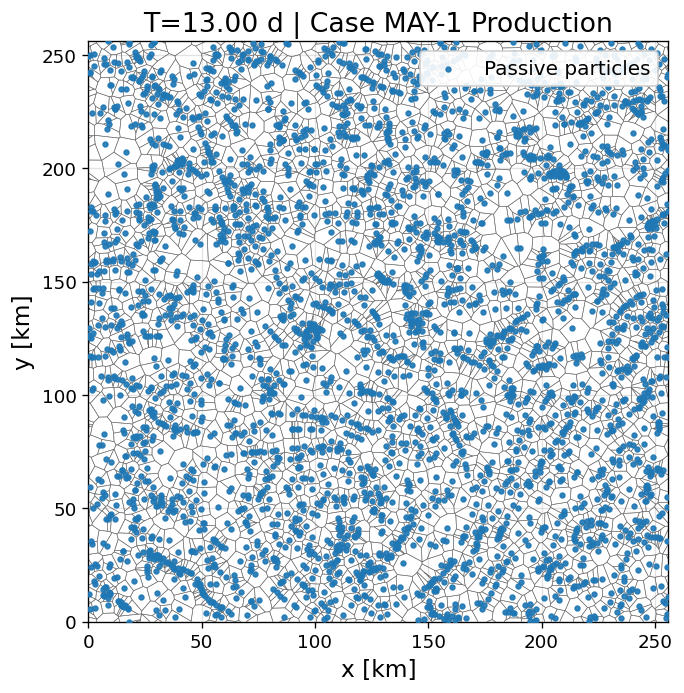

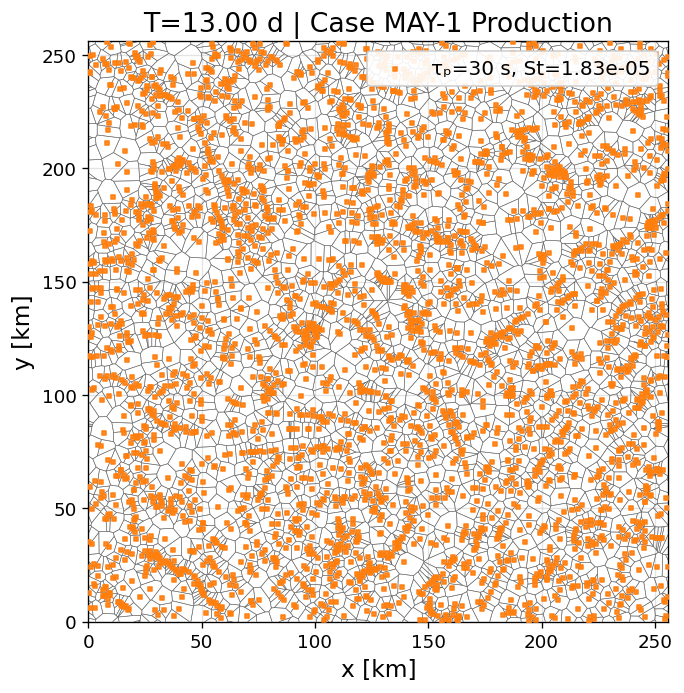

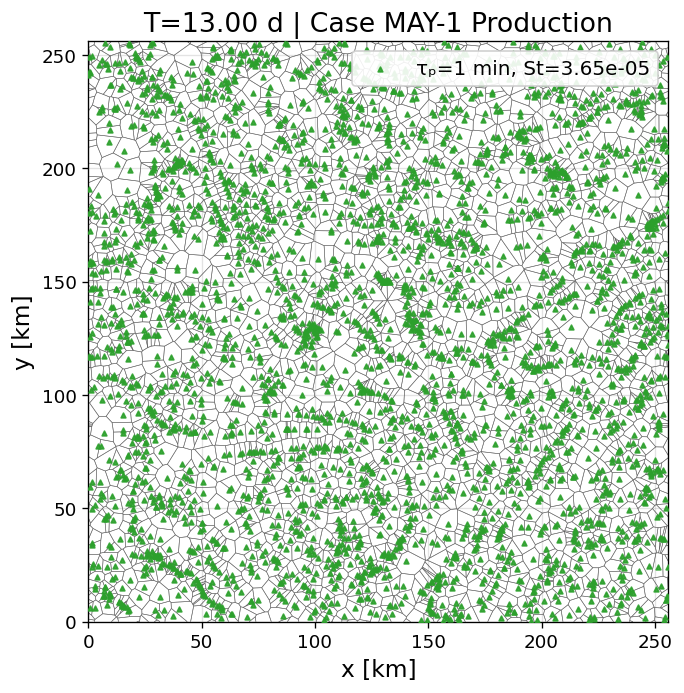

In [ ]:
# ============================================================
# 8. VORONOÏ SNAPSHOTS
# ============================================================

for obs_idx in snapshot_obs_indices:
    elapsed_days = phelp.get_elapsed_time_days(reference_ds, obs_idx)

    for particle_tag, item in trajectories.items():
        ds = item["ds"]
        label = item.get("display_label", item.get("label", particle_tag))
        style = class_style_map[particle_tag]
        xname, yname = phelp.get_xy_names(ds)

        x = ds[xname].isel(obs=obs_idx).values
        y = ds[yname].isel(obs=obs_idx).values
        result = mclus.periodic_voronoi_snapshot(x=x, y=y, domain=domain)

        fig, ax = plt.subplots(figsize=phelp.get_figsize("map"), facecolor="white")
        ax.set_facecolor("white")

        mclus.plot_voronoi_snapshot(
            ax=ax,
            pieces=result["pieces"],
            x=x,
            y=y,
            domain=domain,
            line_color=getattr(ptheme, "VORONOI_LINE_COLOR", "0.35"),
            point_color=style["color"],
            point_marker=style["marker"],
            point_size=getattr(ptheme, "VORONOI_POINT_SIZE", 8),
            point_alpha=getattr(ptheme, "VORONOI_POINT_ALPHA", 0.9),
            line_width=getattr(ptheme, "VORONOI_LINE_WIDTH", 0.35),
            line_alpha=getattr(ptheme, "VORONOI_LINE_ALPHA", 0.75),
            km=True,
            label=label,
        )

        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
        ax.grid(True, alpha=getattr(ptheme, "GRID_ALPHA", 0.35))
        ax.legend(loc="upper right", fontsize=getattr(ptheme, "LEGEND_FONTSIZE", 12))
        ax.set_title(phelp.short_time_title(RUN_TITLE_INFO, elapsed_days))
        fig.tight_layout()

        phelp.savefig_if_enabled(
            fig,
            voronoi_fig_dir / f"{particle_tag}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}_voronoi_obs{obs_idx:04d}.png",
            save=SAVE_FIGURES,
        )

        plt.show()


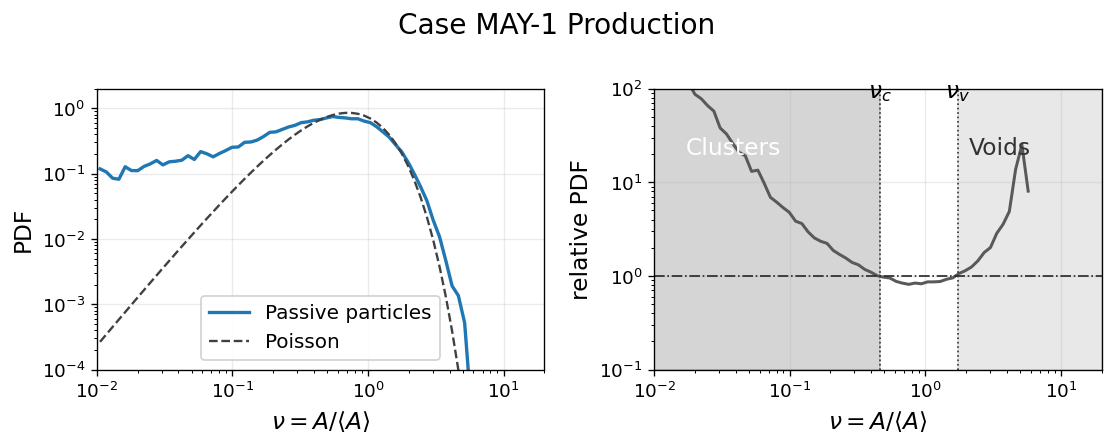

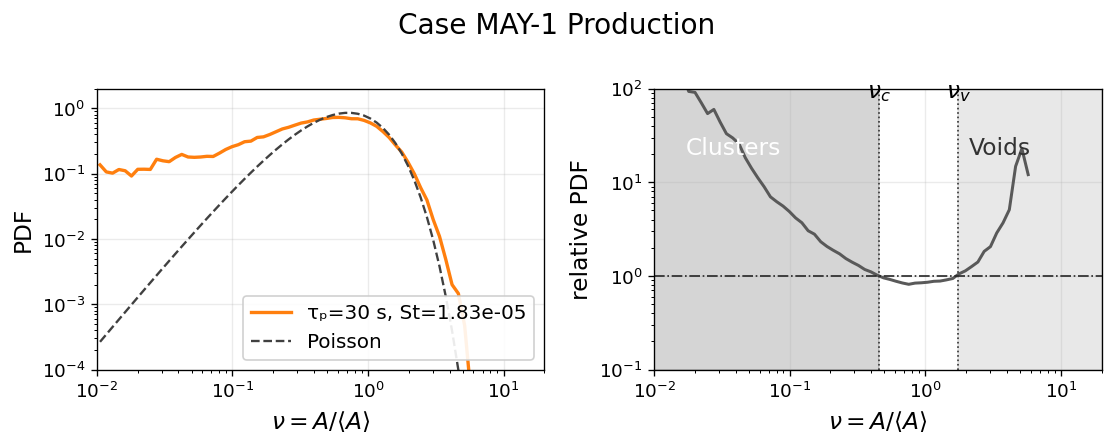

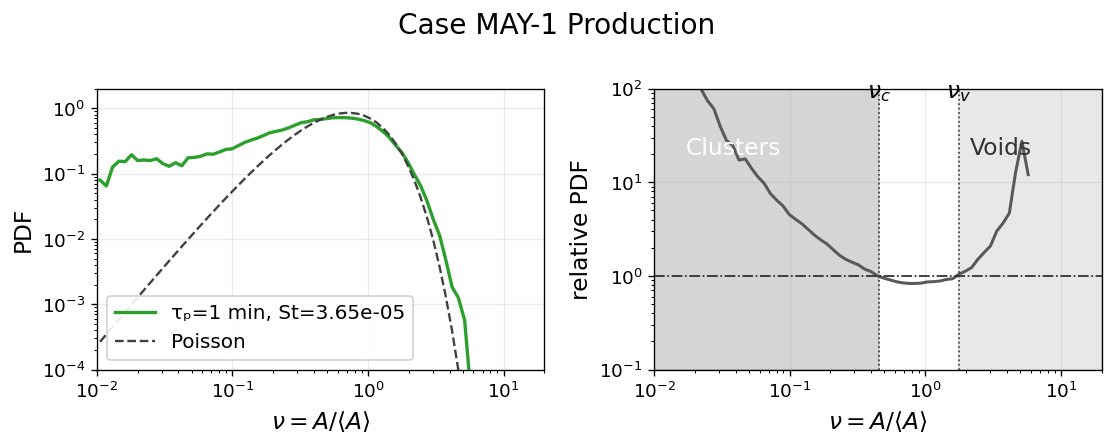

In [ ]:
# ============================================================
# 9. MONCHAUX-STYLE VORONOÏ AREA PDF
# ============================================================

plt.close("all")

for particle_tag, item in trajectories.items():
    label = item.get("display_label", item.get("label", particle_tag))
    style = class_style_map[particle_tag]
    pdf_ds = voronoi_outputs[particle_tag]["pdf"]

    fig, axes = mclus.plot_voronoi_pdf_monchaux(
        pdf_ds,
        particle_label=label,
        color=style["color"],
        title_prefix=RUN_TITLE_INFO,
    )

    if SAVE_FIGURES:
        fig.savefig(
            pdf_fig_dir / (
                f"{particle_tag}_{level_tag}_"
                f"release_t{RELEASE_TIME_INDEX:04d}_"
                f"voronoi_pdf_monchaux.png"
            ),
            dpi=250,
            facecolor="white",
            bbox_inches="tight",
        )


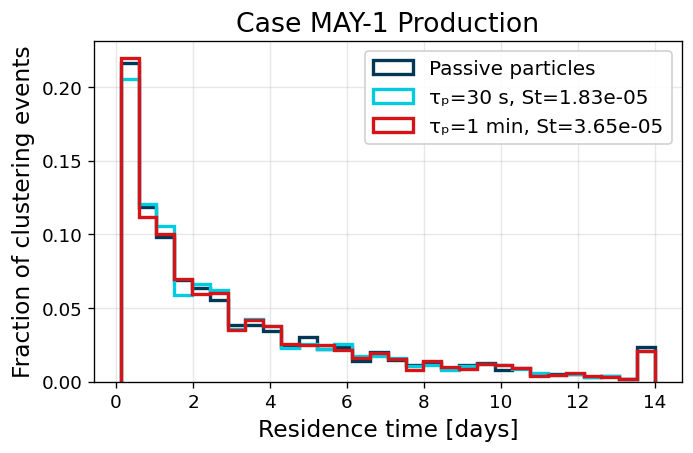

,particle_tag,label,nu_c_fixed,n_events,n_complete_events,n_censored_events,mean_days,median_days,p95_days,max_days
0,passive,Passive particles,0.463732,3082,1672,1410,3.204007,1.875,10.5,14.0
1,smmrg_taueff30s_Steff1p82742em05,"τₚ=30 s, St=1.83e-05",0.458749,3031,1646,1385,3.213502,2.000,10.5,14.0
2,smmrg_taueff60s_Steff3p65483em05,"τₚ=1 min, St=3.65e-05",0.455047,3024,1657,1367,3.186095,1.875,10.5,14.0


In [ ]:
# ============================================================
# 10. PARTICLE CLUSTERED-STATE RESIDENCE-TIME PDF
# ============================================================

fig, ax = plt.subplots(figsize=phelp.get_figsize("small"), facecolor="white")
ax.set_facecolor("white")

for particle_tag, item in trajectories.items():
    label = item.get("display_label", item.get("label", particle_tag))
    style = class_style_map[particle_tag]
    events = clustered_state_outputs[particle_tag]["events"]

    mclus.plot_clustered_state_residence_pdf(
        events,
        ax=ax,
        bins=30,
        label=label,
        color=style["color"],
        title=None,
        complete_events_only=RESIDENCE_COMPLETE_EVENTS_ONLY,
    )

# Preserve the user's title and legend configuration.
ax.set_title(RUN_TITLE_INFO)
ax.legend(
    loc="upper right",
    fontsize=getattr(ptheme, "LEGEND_FONTSIZE", 12),
)
fig.tight_layout()

phelp.savefig_if_enabled(
    fig,
    clustered_state_fig_dir / (
        f"{case_name}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}_"
        "clustered_state_residence_pdf.png"
    ),
    save=SAVE_FIGURES,
)

plt.show()


# Compact clustered-state residence summary table.
rows = []
for particle_tag, item in trajectories.items():
    label = item.get("display_label", item.get("label", particle_tag))
    rs = clustered_state_outputs[particle_tag]["summary"]

    rows.append({
        "particle_tag": particle_tag,
        "label": label,
        "nu_c_fixed": float(
            cluster_outputs[particle_tag].attrs[
                "fixed_cluster_threshold_area_norm"
            ]
        ),
        "n_events": int(rs["n_events"].values),
        "n_complete_events": int(rs["n_complete_events"].values),
        "n_censored_events": int(rs["n_censored_events"].values),
        "mean_days": float(rs["mean_days"].values),
        "median_days": float(rs["median_days"].values),
        "p95_days": float(rs["p95_days"].values),
        "max_days": float(rs["max_days"].values),
    })

display(pd.DataFrame(rows))


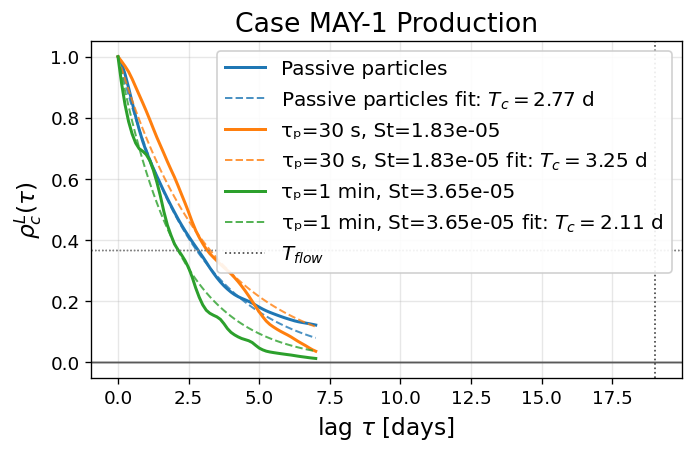

,particle_tag,label,T_c_expfit_days,T_c_efold_days,T_c_integral_days,fit_R2,T_c/T_flow
0,passive,Passive particles,2.772800,2.829476,2.628111,0.998527,0.145931
1,smmrg_taueff30s_Steff1p82742em05,"τₚ=30 s, St=1.83e-05",3.253915,3.147161,2.872274,0.965485,0.171252
2,smmrg_taueff60s_Steff3p65483em05,"τₚ=1 min, St=3.65e-05",2.114805,2.126424,1.887778,0.963289,0.111301


In [ ]:
# ============================================================
# 11. LAGRANGIAN VORONOÏ-CONCENTRATION AUTOCORRELATION
# ============================================================

fig, ax = plt.subplots(figsize=phelp.get_figsize("small"), facecolor="white")
ax.set_facecolor("white")

for particle_tag, item in trajectories.items():
    label = item.get("display_label", item.get("label", particle_tag))
    style = class_style_map[particle_tag]

    mclus.plot_lagrangian_voronoi_concentration_autocorrelation(
        autocorr_outputs[particle_tag],
        ax=ax,
        label=label,
        color=style["color"],
        title=None,
        show_fit=True,
    )

flow_timescale_days = collection_config.get("flow_timescale_days")
if flow_timescale_days is None:
    flow_timescale_seconds = collection_config.get("flow_timescale_seconds")
    if flow_timescale_seconds is not None:
        flow_timescale_days = float(flow_timescale_seconds) / 86400.0

if flow_timescale_days is not None and np.isfinite(float(flow_timescale_days)):
    ax.axvline(
        float(flow_timescale_days),
        color="0.25",
        lw=1.0,
        ls=":",
        label=r"$T_{flow}$",
    )

# Match the user's other analysis figures.
ax.set_title(RUN_TITLE_INFO)
ax.legend(
    loc="upper right",
    fontsize=getattr(ptheme, "LEGEND_FONTSIZE", 12),
)
fig.tight_layout()

phelp.savefig_if_enabled(
    fig,
    autocorr_fig_dir / (
        f"{case_name}_{level_tag}_release_t{RELEASE_TIME_INDEX:04d}_"
        "voronoi_concentration_autocorrelation.png"
    ),
    save=SAVE_FIGURES,
)

plt.show()


# Compact clustering-persistence summary table.
rows = []
for particle_tag, item in trajectories.items():
    label = item.get("display_label", item.get("label", particle_tag))
    ac = autocorr_outputs[particle_tag]

    tc = float(ac["timescale_expfit_days"].values)
    te = float(ac["timescale_efold_days"].values)
    ti = float(ac["timescale_integral_days"].values)

    flow_timescale_days = collection_config.get("flow_timescale_days")
    if flow_timescale_days is None:
        flow_timescale_seconds = collection_config.get("flow_timescale_seconds")
        flow_timescale_days = (
            None
            if flow_timescale_seconds is None
            else float(flow_timescale_seconds) / 86400.0
        )

    rows.append({
        "particle_tag": particle_tag,
        "label": label,
        "T_c_expfit_days": tc,
        "T_c_efold_days": te,
        "T_c_integral_days": ti,
        "fit_R2": float(ac["fit_r2"].values),
        "T_c/T_flow": (
            tc / float(flow_timescale_days)
            if flow_timescale_days is not None
            and np.isfinite(tc)
            and float(flow_timescale_days) > 0.0
            else np.nan
        ),
    })

display(pd.DataFrame(rows))
